In [1]:
import os
import re
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
import matplotlib.cm as mcm
import matplotlib.colors as mcol
from matplotlib.gridspec import GridSpec
from matplotlib import ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.image as mpimg
from astropy.cosmology import Planck18 as cosmo
from morph import *

plt.style.use('./presentation.mplstyle')


In [2]:
cutout_list = os.listdir("post_cutouts/")

sources = pd.read_csv('v1saga_dwarfs.csv')
print(sources.shape)

smorph = pd.read_csv('saga_morph.csv')
print(smorph.shape)

bands = {'g':[mcm.Blues,'tab:blue'],'r':[mcm.Greens,'tab:green'],'i':[mcm.Oranges,'tab:orange'],'z':[mcm.Reds,'tab:red']}

(6337, 26)
(6211, 78)


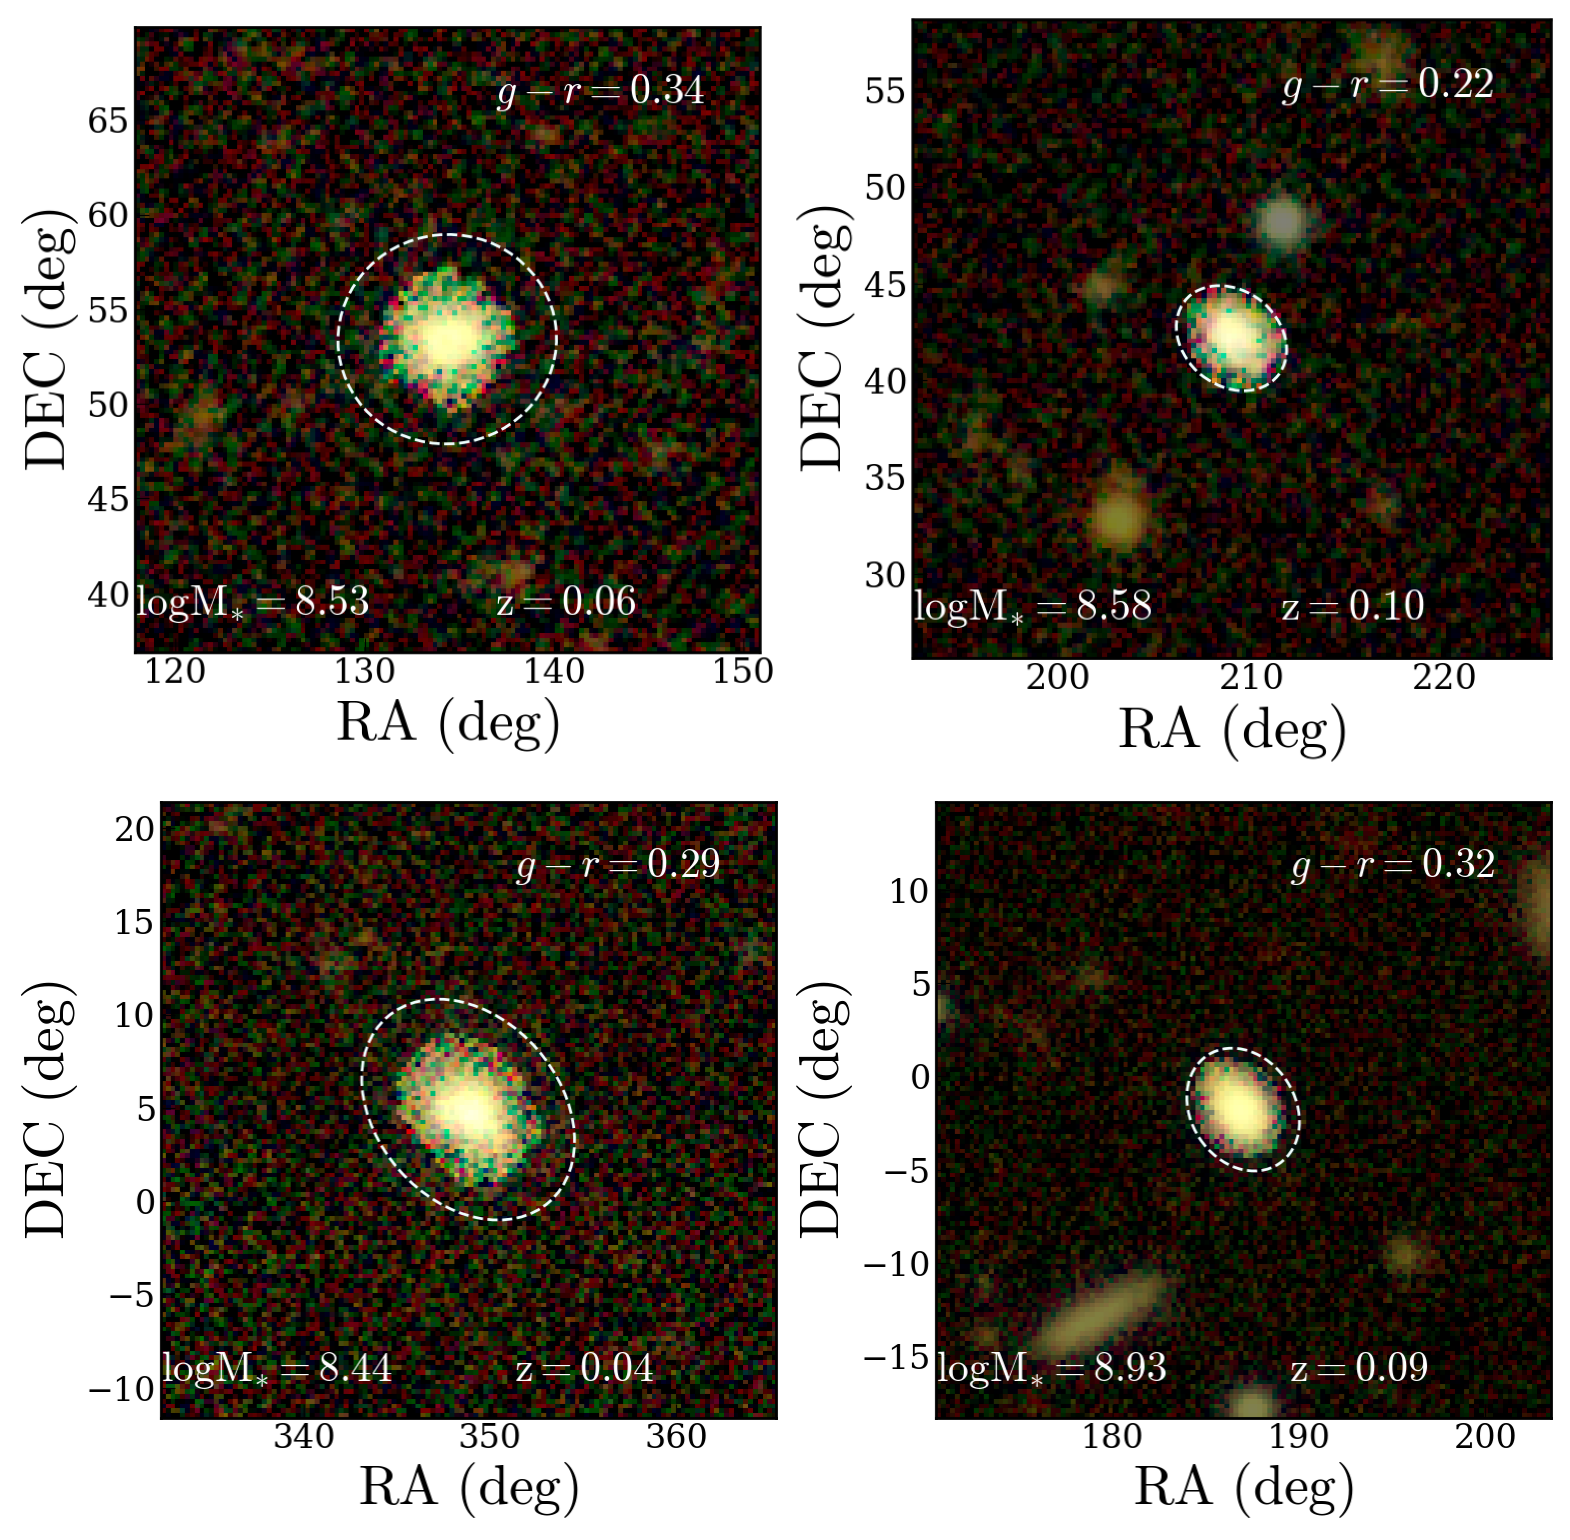

In [10]:

fig,ax=plt.subplots(2,2,figsize=(20,20))

n=0
for i in range(4):
        filename = cutout_list[npr.choice(len(cutout_list))]
        img = mpimg.imread("post_cutouts/"+filename) 
        
        ax[n//2,n%2].imshow(img)
        ax[n//2,n%2].axis('off') # Hide axis ticks               
        n+=1

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('SAGAbg_4samp.pdf',bbox_inches='tight')
plt.show()

In [3]:
#a=1e4
#def _forward(x): return np.log10(a*x + 1)/np.log10(a + 1)
#def _inverse(x): return (np.power(10,x*np.log10(a + 1)) - 1)/a

def band_segmap(img_dat, img_rms, psf_mod, wc, flags):
    segmaps_lo, segmaps_hi = np.zeros((4, npix, npix)), np.zeros((4, npix, npix))
    imzer = np.zeros((npix, npix))

    for iz, key in enumerate(bands):
        if flags[iz] == True:
            continue
        
        # Convolve with PSF model for source detection
        convolved_data = convolve(img_dat[iz], psf_mod)

        # Create segmentation map
        finder = SourceFinder(npixels=10, nlevels=32, contrast=0.0005, progress_bar=False)
        segment_map = finder(convolved_data, img_rms[iz])

        if segment_map == None:
            flags[iz] = True
            continue

        # Identify sources and find the target (brightest near center)
        cat = SourceCatalog(img_dat[iz], segment_map, convolved_data=convolved_data)
        tbl = cat.to_table()

        target = np.argmin(np.sqrt((tbl['xcentroid']-wc[0])**2 +
                                  (tbl['ycentroid']-wc[1])**2))
        
        # Create low and high flux segmentation maps
        segmaps_lo[iz] = (1 * (segment_map == (target+1)))
        segmaps_hi[iz] = (1 * ((segment_map != imzer) & (segment_map != (target+1))))

    return segmaps_hi, segmaps_lo, flags


0
1
1
1
2


2
3
3
3
4
4
4


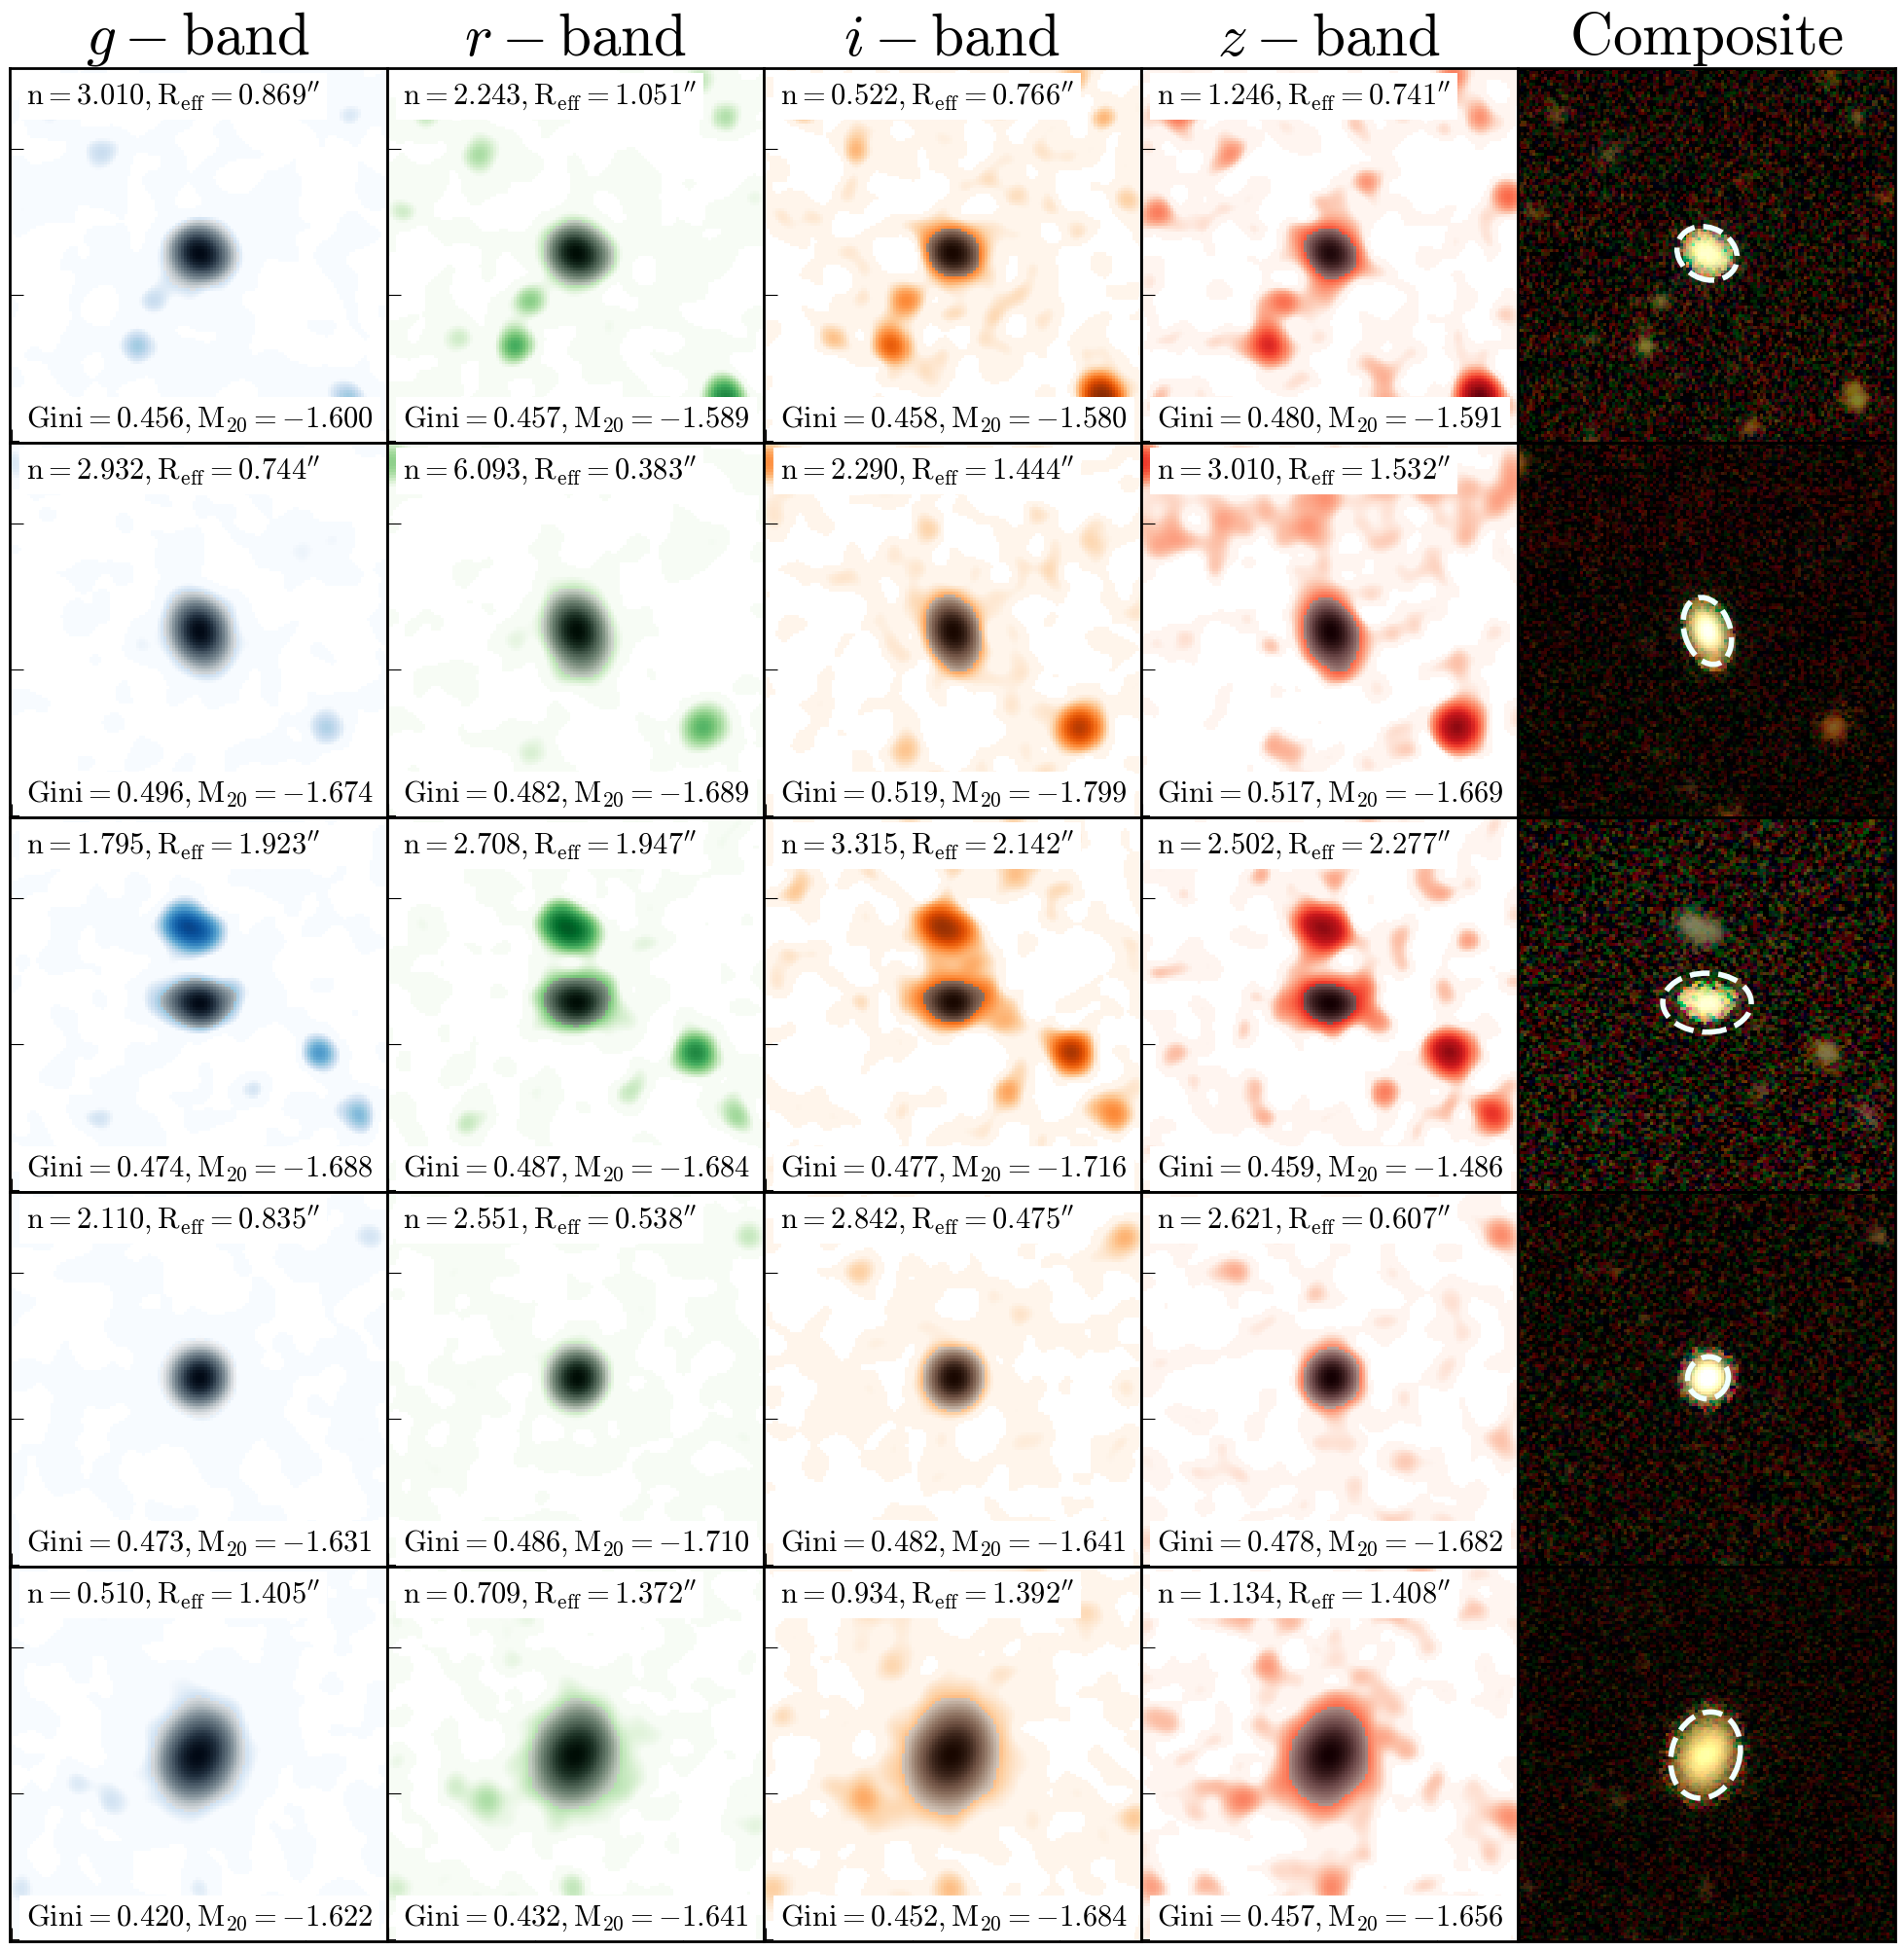

In [6]:
#fig = plt.figure(figsize=(40, 16))
#gs = GridSpec(16, 16, figure=fig)
model_psf = psf_grid(d_psf=8, fwhm=3)  # Generic PSF for source finding
fig,ax=plt.subplots(5,5,figsize=(25,25),sharex=True,sharey=True)

sources['ra'],sources['dec'] = sources['ra'].round(4),sources['dec'].round(4)
dfac = 0.262
n=0
while n<5:
        print(n)
        filename = cutout_list[npr.choice(len(cutout_list))]
        pos = [float(p) for p in re.findall(r"[-+]?(?:\d*\.*\d+)", filename)]
        data = fits.open('cutouts/cutout_{:.4f}_{:.4f}.fits'.format(pos[0], pos[1]))

        sourc_ind = int(sources.loc[(sources['ra'] == pos[0])&(sources['dec'] == pos[1]),'ind'].item())
        #sourc_zsp = sources.loc[(sources['ra'] == pos[0])&(sources['dec'] == pos[1]),'zspec'].item()
        smorph_row = smorph[smorph['ind0']==sourc_ind]
        if (smorph_row['snr_pix_z'].item()<2.5) and (smorph_row['flag_z'].item()>0) and (smorph_row['r20_psf_z'].item()<0.5): continue
        #dfac = cosmo.comoving_distance(sourc_zsp).value*np.pi/(180*3600)
        #print(smorph_row)

        # Background subtraction
        img_data, img_hdr, img_rms, glob_rms, flags = image_bkg(data)
        if np.any(flags): continue

        # Get WCS and convert to pixel coordinates
        w = wcs.WCS(img_hdr, naxis=2)
        pos_coord = SkyCoord(ra=pos[0]*u.degree, dec=pos[1]*u.degree, frame='icrs')
        wc = [int(i) for i in w.world_to_pixel(pos_coord)]
        imext = [pos[0]-16.506, pos[0]+16.506, pos[1]-16.506, pos[1]+16.506]

        # Source segmentation
        segmaps_hi, segmaps_lo, flags = band_segmap(img_data, img_rms, model_psf, wc, flags)

        # Combine across bands (g and r required)
        if not (flags[0] or flags[1]):
            comp_segmap = 1 * (np.logical_and(segmaps_lo[0], segmaps_lo[1]) &
                           (np.logical_xor(segmaps_lo[2], flags[2]) |
                            np.logical_xor(segmaps_lo[3], flags[3])))
        #comp_mask = 1 * np.logical_or(np.logical_or(segmaps_hi[0], segmaps_hi[1]),np.logical_or(segmaps_hi[2], segmaps_hi[3]))
        else: continue
    
        # Verify target is near center
        if comp_segmap[npix//2 - 1, npix//2 - 1] < 1: continue

        #axl = np.array([[fig.add_subplot(gs[4*n:(4*n+2), 0]),fig.add_subplot(gs[4*n:(4*n+2), 1])],[fig.add_subplot(gs[(4*n+2):(4*n+4), 0]),fig.add_subplot(gs[(4*n+2):(4*n+4), 1])]]) # Top-left 2x2
        #axr = fig.add_subplot(gs[4*n:(4*n+4), 2:4])

        for j,key in enumerate(bands):
            convolved_img = convolve(img_data[j], model_psf)

            #m, s = np.mean(convolved_img), np.std(convolved_img)
            norm = mcol.LogNorm(vmin=1e-3, vmax=np.amax(convolved_img))
            ax[n,j].imshow(convolved_img, interpolation='nearest', cmap=bands[key][0],norm=norm,origin='lower',aspect='auto')
            
            #img_copy = img_data[j].copy()
            for k in range(3): np.putmask(convolved_img, ~(segmaps_lo[j].astype('bool')), 0)
            ax[n,j].imshow(convolved_img, interpolation='nearest', cmap=mcm.Greys, origin='lower',norm=norm,alpha=0.8,aspect='auto')
            ax[n,j].text(5, 5,r'$Gini={:.3f},M_{{20}}={:.3f}$'.format(smorph_row['gini_'+key].values[0],smorph_row['m20_'+key].values[0]) ,fontsize=22,bbox=dict(facecolor='white', alpha=1.0, edgecolor='none', pad=5))
            ax[n,j].text(5,115,r'$n={:.3f},R_{{\rm eff}}={:.3f}^{{\prime \prime}}$'.format(smorph_row['n_'+key].values[0],smorph_row['rhalf_'+key].values[0]*dfac) ,fontsize=22,bbox=dict(facecolor='white', alpha=1.0, edgecolor='none', pad=5))
    
        img_copy = [img_data[k].copy() for k in [0, 1, 3]]
    
        ax[n,-1].imshow(rgb_cutout(img_copy), origin='lower',aspect='auto')
    
        for k in range(3): np.putmask(img_copy[k], ~(comp_segmap.astype('bool')), 0)
        ax[n,-1].imshow(rgb_cutout(img_copy), origin='lower',alpha=0.5,aspect='auto')

        
        e = Ellipse(xy=[smorph_row['xc_as_r'].values, smorph_row['yc_as_r'].values],
                   width=2*smorph_row['rpetro_r'].values, height=2*smorph_row['rpetro_r'].values*(1-smorph_row['ellip_as_r'].values),
                   angle=smorph_row['orien_as_r'].values*180/np.pi, lw=4, fill=False, color='azure', ls='--')
        ax[n,-1].add_artist(e)
        
        #ax[n,-1].imshow(img)
        #ax[n,-1].axis('off') # Hide axis ticks 
        #ax[n,0].set_ylabel(r'$DEC \ (deg)$', fontsize=40)
        ax[n,0].tick_params(labelbottom=False, labelleft=False)
        n+=1

for j,key in enumerate(bands):
    ax[0,j].set_title(r'${\it '+key+'}-band$',fontsize=44)
    ax[-1,j].tick_params(labelbottom=False, labelleft=False)
    #ax[-1,j].set_xlabel(r'$RA \ (deg)$', fontsize=40)
ax[-1,-1].tick_params(labelbottom=False, labelleft=False)
ax[0,-1].set_title(r'$Composite$',fontsize=44)

plt.subplots_adjust(wspace=0,hspace=0)
plt.savefig('SAGAmorph_4column.pdf',bbox_inches='tight')
plt.show()